In [123]:
import pandas as pd

def print_full(x):
    with pd.option_context('display.max_columns', None):
        display(x)


### Use DeGiro as a model
* Look through the data they provide, and confirm that using the latest data from AV I can reproduce their numbers
* Then will be in a position to do this with historical data
* Look for useful metrics that suggest good options (a historical screener), and then see if their price goes up


#### 1. Using the RATIOS screen

In [124]:
# Bundle the De Giro stuff here since its only for quick comparison
class RatiosDG():

    dgxl = pd.read_excel('DeGiro-Ratios.xlsx', sheet_name=None, header=None)
    
    # Note: sheet will be 0-indexed so use (row_number-1) in the cellRef calls
    def cellRef(tickers, row, col):
        if (tickers):
            if (isinstance(tickers, str)):
                tickers = [tickers]
        else:
            tickers = RatiosDG.dgxl.keys()
        return pd.Series({i:RatiosDG.dgxl[i].iloc[row,col] for i in tickers})

    def revenueTTM(tickers = False):
        return RatiosDG.cellRef(tickers,20,1)
    def revenueLFY(tickers = False):
        return RatiosDG.cellRef(tickers,20,2)

    def ebitdaTTM(tickers = False):
        tickers = RatiosDG.dgxl.keys()
        return RatiosDG.cellRef(tickers, 21,1)
    def ebitdaLFY(tickers = False):
        tickers = RatiosDG.dgxl.keys()
        return RatiosDG.cellRef(tickers, 21,2)

    def peTTM(tickers = False):
        return RatiosDG.cellRef(tickers, 41, 2)
    def peLFY(tickers = False):
        return RatiosDG.cellRef(tickers, 40, 3)
    
    def currentMRQ(tickers=False):
        return RatiosDG.cellRef(tickers, 59, 1)
    def currentLFY(tickers=False):
        return RatiosDG.cellRef(tickers, 59, 3)
    
    def fcfMRQ(tickers):
        return RatiosDG.cellRef(tickers, 61,1)
    def fcfTTM(tickers):
        return RatiosDG.cellRef(tickers, 61,2)

    def bpsMRQ(tickers=False):
        return RatiosDG.cellRef(tickers, 81, 1)
    def bpsTTM(tickers=False):
        return RatiosDG.cellRef(tickers, 81, 2)

    def pbMRQ(tickers=False):
        return RatiosDG.cellRef(tickers, 49, 1)
    
RatiosDG.pbMRQ()



AAPL     32.55
MSFT     11.63
ADBE     12.34
GOOG      5.78
BABA      1.99
IMKTA     1.45
OXY       3.45
QCOM     10.28
DIS       1.84
dtype: float64

In [131]:
# Plot
# Assumes the seaborn library has already been loaded (load it here as well?)
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

class Plot():
    
    def line(tickers):
        melted = tickers.reset_index()
        if 'index' in melted.columns:
            x = 'index'
        if 'Quarter' in melted.columns:
            x = 'Quarter'
        if 'fiscalDateEnding' in melted.columns:
            x = 'fiscalDateEnding'
        melted = melted.melt(id_vars=[x]).dropna(subset=['value'])
        plt.figure(figsize=(9, 6))
        sns.set_style("white")
        g = sns.lineplot(data=melted, x=x, y='value', hue=melted.columns[1])
        # Adjust the width of the legend lines
        for leg_line in plt.legend().get_lines():
            plt.setp(leg_line, linewidth=6)
        plt.show(g)
        
    def pretty_plot(data):
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan' ]
        fig, ax = plt.subplots(figsize=(12,9))

        for l,i in enumerate(data.columns):
            col = colors[l]
            line = data[i].dropna()
            ax.plot(line.index, line, color=col, label=i)
        ax.xaxis.set_major_locator(matplotlib.dates.YearLocator())
        ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y"))
        fig.autofmt_xdate()
        plt.legend(handlelength=4)

        # Adjust the width of the legend lines
        for leg_line in plt.legend().get_lines():
            plt.setp(leg_line, linewidth=6)
        plt.show()


In [144]:
# Run the module that Ratios will be built on Macro Trends or Alpha Vantage
#%run AlphaVantage.ipynb
%run MacroTrends.ipynb


class Ratios(MT):

    # Compare AV result with DeGiro result
    def compare(fn, tickers, divide=0):
        av = eval(f'AlphaVantage.{fn}({tickers}) / 1e{divide}')
        dg = eval(f'RatiosDG.{fn}({tickers})')
        m = pd.concat([av, dg], axis=1)
        return m

    # rollingFiveYear
    # Assumes it is receiving a column of quarterly numbers - performs a rolling 5 year (20 quarters) average
    # Note: not enough data for this to generate a number...
    def rollingFiveYear(col):
        return col.dropna().rolling(window=20).mean()

    # Market Cap Latest - supply a latest price and it will generate the current market cap
    # Note: this only accepts a single ticker since it only accepts a single price
    def marketCapLatest(ticker, price):
        if (isinstance(ticker, str)):
            ticker = [ticker]
        tso = Ratios.totalSharesOutstanding(ticker)
        return (tso * price).iloc[-1]
    
    # EV Latest - similar to above, uses the latest Market Cap to generate a latest EV value
    def EVLatest(ticker, price):
        if (isinstance(ticker, str)):
            ticker = [ticker]
        mc = Ratios.marketCapLatest(ticker, price)
        debt = Ratios.totalLiabilities(ticker).apply(Ratios.MRQ, axis=0)
        cash = Ratios.currentAssets(ticker).apply(Ratios.MRQ, axis=0)
        return (mc + debt - cash)

    # Compare the calculated version of Total Shareholder Equity against the supplied value
    # Some discrepancy...
    def TSE(tickers):
        tse = Ratios.balanceq.loc[tickers]['totalShareholderEquity'].unstack(level=0).sort_index()
        return tse
    
    def compareTSE(tickers):
        tse = Ratios.totalShareholderEquity(tickers)
        av = Ratios.balanceq.loc[tickers]['totalShareholderEquity'].unstack(level=0).sort_index()
        c = 100* (tse/av)
        return c[ (c > 130) | (c < 70)].count()


    # Compare TSO - compare total shares outstanding
    # Comparing AV data with itself - via the overview which gives the most uptodate quarter numbers...
    def compareTSO(tickers):
        tso = Ratios.totalSharesOutstanding(tickers).apply(Ratios.MRQ)
        overview = Ratios.overview.loc[tickers]['SharesOutstanding']
        return 100 * tso / overview
    
    # List of ratios along with a log of accuracy against macrotrends data
    #
    # Current: AAPL 100%
    # Quick: AAPL 100%
    # Debt/Equity: AAPL 100% DELL 99%
    # ROA: AAPL 100%
    # ROI: slightly off even though source data seems right (rolling mean?)
    # ROE: AAPL 100%
    # - Asset Turnover:
    # - Equity leverage:
    # Margins:
    # - Gross
    # - Operating
    # - EBITDA: AAPL 100% (using new EBITDA measure)
    # - Net
    # EV Ratios: Generally not very accurate since EV relies on Market Cap which relies on latest prices
    # - EV: 
    # - EV/Sales:
    # - EV/EBITDA: EBITDA 100% match with Seeking Alpha, but EV is clearly different
    # - EV/EBIT: as above
    # Price Ratios:
    # - Price Earnings
    # - Price Sales
    # - Price Book
    # - Price FCF
    # Magic Formula Ratios:
    # - Earnings Yield
    # - ROIC
    #
    
    # Current Ratio: Current Assets / Current Liabilities
    #
    def current(tickers):
        tca = Ratios.currentAssets(tickers)
        tcl = Ratios.currentLiabilities(tickers)
        return tca / tcl
    
    # Quick Ratio: Current Assets - Inventory / Current Liabilities
    # Similar to current ratio but assumes inventory can't be easily turned into cash so removed from assets
    def quick(tickers):
        tca = Ratios.currentAssets(tickers)
        tcl = Ratios.currentLiabilities(tickers)
        inv = Ratios.inventory(tickers)
        return (tca - inv) / tcl

    # Debt to Equity - Long-term debt / Shareholder equity
    # How much debt has the company taken on relative to its shareholder equity
    # Macrotrends uses totalLiabilities in the numerator - DOES IT? Doesn't do it for DELL
    #
    def debtEquity(tickers):
        debt = Ratios.longtermDebt(tickers)
        tse = Ratios.totalShareholderEquity(tickers)
        return (debt / tse)

    # ROE (Return on Equity) - Net Income / totalShareholderEquity
    #
    # Note: source numbers match with macrotrends, but calculated return is slightly off on macrotrends
    # It looks like they average out the last 4 quarters of shareholders equity to smooth it out - try this
    def ROE(tickers):
        ni = Ratios.netIncome(tickers).apply(Ratios.rollingTTM)
        tse = Ratios.totalShareholderEquity(tickers)
        return 100 * (ni / tse)

    # ROA (Return on Assets) - netIncome / totalAssets
    #
    # As with ROE, data matches but calculated % is off (correct against Seeking Alpha)
    # As for ROE use an average of last 4 quarters of assets whne comparing with Macro Trends, but not for Old School Value
    def ROA(tickers):
        ni = Ratios.netIncome(tickers).apply(Ratios.rollingTTM)
        a = Ratios.totalAssets(tickers)
        return 100 * (ni / a)
    
    # ROI (Return on Investment) - EBIT / Long Term Investments and Debt
    # Note: using the Macro Trends definition since this is the one I can compare with: long-term debt + shareholder equity is the denominator
    # Note also the numerator is EBIT not net Income (don't know why MT does this but it does)
    # Return on Capital ROC (below) uses the Magic Formula definition - very different results
    def ROI(tickers):
        ni = Ratios.EBIT(tickers).apply(Ratios.rollingTTM)
        debt = Ratios.longtermDebt(tickers)
        tse = Ratios.totalShareholderEquity(tickers)
        return 100 * (ni / (debt + tse))
    

    # DuPont Analysis of ROE
    #
    # ROE can be divided into three components:
    # netMargin: netIncome / Revenue
    # assetTurnover: Revenue / Assets
    # equityLeverage:Assets / Shareholder Equity
    # Multiplying these 3 results in the ROE: netIncome / Shareholder Equity
    #
    # netMargin already defined as part of the margins section (note this is a %)
    def assetTurnover(tickers):
        rev = Ratios.revenue(tickers).apply(Ratios.rollingTTM)
        assets = Ratios.totalAssets(tickers)
        return (rev / assets)
    
    def equityLeverage(tickers):
        assets = Ratios.totalAssets(tickers)
        tse = Ratios.totalShareholderEquity(tickers)
        return (assets / tse)

    
    ##############
    # Margins - all margins are expressed as a %
    #
    # Note: since total revenue is impossible to match with AV revenue data these margins will often be slightly out
    
    # Gross Margin: Gross Profit / Total Revenue
    def grossMargin(tickers):
        gp = Ratios.grossProfit(tickers).apply(Ratios.rollingTTM)
        rev = Ratios.revenue(tickers).apply(Ratios.rollingTTM)
        return 100 * (gp / rev)
    
    def operatingMargin(tickers):
        op = Ratios.operatingIncome(tickers).apply(Ratios.rollingTTM)
        rev = Ratios.revenue(tickers).apply(Ratios.rollingTTM)
        return 100 * (op / rev)
    
    def EBITDAMargin(tickers):
        e = Ratios.EBITDA(tickers).apply(Ratios.rollingTTM)
        rev = Ratios.revenue(tickers).apply(Ratios.rollingTTM)
        return 100 * (e / rev)
    
    def netMargin(tickers):
        n = Ratios.netIncome(tickers).apply(Ratios.rollingTTM)
        rev = Ratios.revenue(tickers).apply(Ratios.rollingTTM)
        return 100 * (n / rev)
    
    
    ##############
    # EV: Enterprise Value
    #
    # Comprehensive measure of value built on market value + debts - cash
    # Most useful to compare companies at similar stages of growth: younger companies have less debt and more growth potential
    # Hard to validate this, can't find good examples of historical EV, macrotrends doesn't report this number...
    def EV(tickers):
        mc = Ratios.marketCap(tickers)
        debt = Ratios.totalLiabilities(tickers)
        cash = Ratios.currentAssets(tickers)
        return (mc + debt - cash)
    
    # EVSales: EV / total Revenue
    # A measure of how much you'd pay for each $ of sales
    # Note: must use the rolling TTM sales otherwise the ratio gets skewed
    def EVSales(tickers):
        ev = Ratios.EV(tickers)
        rev = Ratios.revenue(tickers).apply(Ratios.rollingTTM, axis=0)
        return (ev / rev)

    # EV / EBIT
    # Seeking Alpha has this value, so include it here as a way of checking my EV and EBIT values
    # Note: this is the inverse of earnings yield defined later
    def EVEBIT(tickers):
        ev = Ratios.EV(tickers)
        ebit = Ratios.EBIT(tickers).apply(Ratios.rollingTTM, axis=0)
        return (ev / ebit)

    # EV / EBITDA
    # Seeking Alpha has this value, so include it here as a way of checking my EV and EBITDA values
    def EVEBITDA(tickers):
        ev = Ratios.EV(tickers)
        ebitda = Ratios.EBITDA(tickers).apply(Ratios.rollingTTM, axis=0)
        return (ev / ebitda)

    
    ##############
    # Price Ratios
    #
    # Note: Two issues with Price Ratios
    # 1. Price data is currently only weekly, the price will often be slightly out
    # 2. Outstanding shares seems to be slightly off, meaning all per-share ratios will be off
    
    # Price / Earnings
    #
    # Note: this is a rolling amount since its based on annual earnings
    def pe(tickers):
        e = Ratios.eps(tickers).apply(Ratios.rollingTTM, axis=0)
        return Ratios.priceRatio(e)

    # Price / Sales
    #
    def ps(tickers):
        s = Ratios.revenue(tickers).apply(Ratios.rollingTTM, axis=0)
        tso = Ratios.totalSharesOutstanding(tickers)
        return Ratios.priceRatio(s / tso)

    # Price / Book
    #
    # Book Value per share - total shareholder equity / number of shares outstanding
    # Notionally the value of each share if the company were liquidated
    def bpsRolling(tickers):
        tse = Ratios.totalShareholderEquity(tickers)
        tso = Ratios.totalSharesOutstanding(tickers)
        return (tse / tso)
 
    def pb(tickers):
        b = Ratios.bpsRolling(tickers)
        return Ratios.priceRatio(b)

    # Price / Free Cash Flow
    #
    # Free Cash Flow: Cash From Operations - Capital Expenditures - Dividends
    # Note: Seeking Alpha, Macrotrends FCF ignores dividends just Cash From Operations - CAPEX
    # AV: Cash from Operations = operatingCashflow
    def fcf(tickers):
        cfo = Ratios.operatingCashflow(tickers)
        ce = Ratios.capitalExpenditures(tickers)
        return cfo - ce

    def fcfRolling(tickers):
        f = Ratios.fcf(tickers)
        return f.apply(Ratios.rollingTTM, axis=0)

    # Free Cash Flow per share - divide FCF by shares outstanding
    #
    # Note: since this is a per-share ratio it will always be rolling
    def fcfpsRolling(tickers):
        fcf = Ratios.fcfRolling(tickers)
        tso = Ratios.totalSharesOutstanding(tickers)
        return (fcf / tso)

    def pfcf(tickers):
        fcf = Ratios.fcfpsRolling(tickers)
        return Ratios.priceRatio(fcf)
        
    ##############
    # MAGIC FORMULA RATIOS
    #
    # Joel Greenblatts Magic Formula which claims to beat the market
    #
    # Earnings Yield: EBIT / EV
    # Higher is better
    def earningsYield(tickers):
        ebit = Ratios.EBIT(tickers).apply(Ratios.rollingTTM, axis=0)
        ev = Ratios.EV(tickers)
        return 100 * (ebit / ev)
    
    # ROC (Return on  Capital):
    # Lots of competing definitions here...
    # Magic Formula: EBIT / (Net Fixed Assets + Working Capital)
    # Working Capital = Current Assets - Current Liabilities
    # A futher step for working capital: Current Assets - (Current Liabilities - Current Debt)
    # Net Fixed Assets = Property, Plants - Depreciation
    # Old School Value has a denomonator of Total Debt + Shareholder Equity as an idea of Invested Capital
    # Macrotrends also uses same denominator as Old School Value
    # Use the Magic Formula here since that's the most likely way I'll use it - but tread carefully its hard to know if I've got it right!
    # Following article shows how the ROC or ROIC can vary wildly between different sources https://seekingalpha.com/article/3963244-magic-formula-in-depth-look-mechanics-and-potential-improvement
    #
    # Move netFixedAssets and workingCapital to the data-source classes since they are fudged based on the available data
    # Also, might be better to just use ROI instead of ROC due to hard way to find ROC...
    # Could also experiment with combining ROE, ROA and ROI...?
    def ROC(tickers):
        ebit = Ratios.EBIT(tickers).apply(Ratios.rollingTTM, axis=0)
        nfa = Ratios.netFixedAssets(tickers)
        wc = Ratios.workingCapital(tickers)  
        return 100 * (ebit / nfa + wc)
        

# Test using the tickers I have in my De Giro account
tickers = ['AAPL','MSFT','ADBE','BLDR','NIO','N3IA','GOOG','BABA','ESCA','IMKTA','META','OXY','QCOM','DIS']
# KeyError: "['BLDR' 'NIO' 'N3IA' 'ESCA' 'META'] not in index"
#stocks = ['AAPL','MSFT','ADBE','GOOG','IMKTA','OXY','QCOM','DIS']

#KeyError: "['N3IA' 'META'] not in index"
tickers = ['AAPL','MSFT','ADBE','BLDR','NIO','GOOG','BABA','ESCA','IMKTA','OXY','QCOM','DIS']

# Using the ticker list for which I grabbed data out of De Giro
# Ignore BABA since it reports in Yuan
tickers = ['AAPL','MSFT','GOOG','BABA','IMKTA','OXY','QCOM','DIS']


# UPDATE: Lots of MT data now read... it could be that we switch completely to using MT instead (sigh...)
# Firstly, accept that the data is never going to be 100% perfect - just run with what I have and get some results!
# Secondly, think a bit more before-hand! Lots of time wasted on tasks that are totally unneccesary (eg Alpha Vantage!)

Ratios.EBIT(tickers).apply(Ratios.rollingTTM)


ticker,AAPL,MSFT,GOOG,BABA,IMKTA,OXY,QCOM,DIS
Quarter,,,,,,,,
2009-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-12-31,13364.0,21420.0,8312.0,NaN,106.4768,5289.0,2676.0,5297.0
2010-03-31,15020.0,22155.0,8916.0,NaN,105.6757,6513.0,3462.0,5756.0
2010-06-30,16622.0,24098.0,9407.0,NaN,104.4659,7257.0,3461.0,6422.0
2010-09-30,18385.0,26732.0,9880.0,NaN,109.4461,7799.0,3727.0,6456.0
2010-12-31,21487.0,26384.0,10381.0,NaN,111.2644,7862.0,4095.0,7075.0
2011-03-31,25382.0,26920.0,10189.0,NaN,113.4679,8610.0,4749.0,7162.0


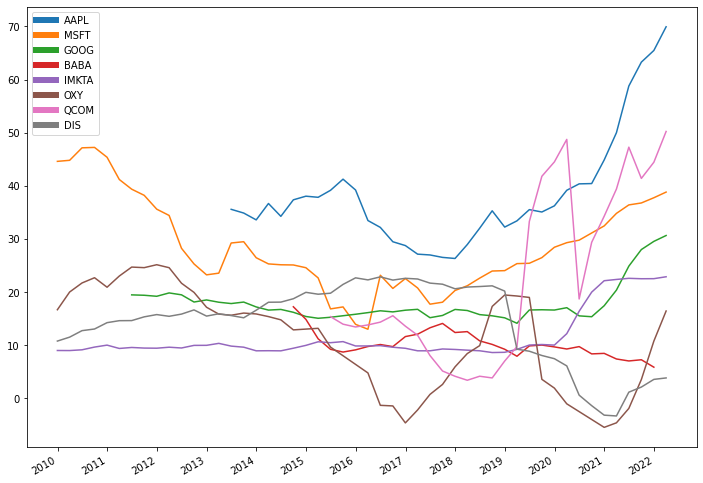

In [132]:
Plot.pretty_plot(Ratios.ROI(tickers))